In [1]:
import tkinter as tk
import pickle
import joblib
import threading
import time
from tkinter import messagebox, ttk
import random
import numpy as np
import pandas as pd
from datetime import datetime
import webbrowser
import sys
import os
import csv
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from playsound import playsound
from tensorflow.keras.models import load_model
from keras.models import load_model
import re
import ctypes  # For DPI fix
from tkinter import font as tkFont
from PIL import Image, ImageTk, ImageDraw, ImageFont

try:
    ctypes.windll.shcore.SetProcessDpiAwareness(1)
except:
    pass
import json
import bcrypt
import hashlib

In [2]:
def get_resource_path(relative_path):
    """Get absolute path to resource (for PyInstaller)"""
    if hasattr(sys, '_MEIPASS'):
        return os.path.join(sys._MEIPASS, relative_path)
    return os.path.abspath(relative_path)


# Load model names
models_list = ['ANN', 'NaiveBayes', 'RandomForestClassifier', 'SVMClassifer','GradientBoostingClassifier'
               , 'XGBoostClassifier', 'Tab2Image_CNN', 'CNN-MLEnsembleNet', 'ML_EnsembleNet']

# Load saved metrics
with open(get_resource_path('Dataset/model_metrics.pkl'), 'rb') as f:
    metrics = pickle.load(f)
    accuracies_list = metrics['accuracies']
    false_positives_list = metrics['false_positives']

# Create dictionaries
models_dict = {
    'ANN': load_model('Model/ann_model.keras'),
    'NaiveBayes': joblib.load('Model/nb_model.pkl'),
    'RandomForestClassifier': joblib.load('Model/rfc_model.pkl'),
    'SVMClassifer': joblib.load('Model/svm_model.pkl'),
    'GradientBoostingClassifier': joblib.load('Model/gbc_model.pkl'),
    'XGBoostClassifier': joblib.load('Model/xgb_model.pkl'),
    'Tab2Image_CNN': load_model("Model/cnn2image_model.keras"),
    'CNN-MLEnsembleNet': 1,
    'ML_EnsembleNet': 2
}
accuracies = {name: round(acc, 3) for name, acc in zip(models_list, accuracies_list)}
false_positives = {name: round(fp, 3) for name, fp in zip(models_list, false_positives_list)}

# Optional: print for verification
print("✅ Accuracies:\n", accuracies)
print("\n❗ False Positives:\n", false_positives)

d:\Anaconda_Python\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator GaussianNB from version 1.5.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Anaconda_Python\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Anaconda_Python\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.7.0. This might lead to breaking code 

✅ Accuracies:
 {'ANN': 0.968, 'NaiveBayes': 0.741, 'RandomForestClassifier': 0.986, 'SVMClassifer': 0.945, 'GradientBoostingClassifier': 0.981, 'XGBoostClassifier': 0.983, 'Tab2Image_CNN': 0.969, 'CNN-MLEnsembleNet': 0.983, 'ML_EnsembleNet': 0.986}

❗ False Positives:
 {'ANN': 0.032, 'NaiveBayes': 0.259, 'RandomForestClassifier': 0.014, 'SVMClassifer': 0.055, 'GradientBoostingClassifier': 0.019, 'XGBoostClassifier': 0.017, 'Tab2Image_CNN': 0.031, 'CNN-MLEnsembleNet': 0.017, 'ML_EnsembleNet': 0.014}


In [3]:
# Load the saved test data
X_test = np.load(get_resource_path("Dataset/X_test.npy"))

print("Loaded X_test:", X_test.shape)

# Extract column names as feature name
features = ['USD', 'BTC', 'Protcol', 'SeddAddress', 'Flag', 'IPaddress', 'Clusters', 'ExpAddress', 'Netflow_Bytes', 'Port']

# Optional: print or display the features
print("Feature Names:")
print(features)

Loaded X_test: (60013, 10)
Feature Names:
['USD', 'BTC', 'Protcol', 'SeddAddress', 'Flag', 'IPaddress', 'Clusters', 'ExpAddress', 'Netflow_Bytes', 'Port']


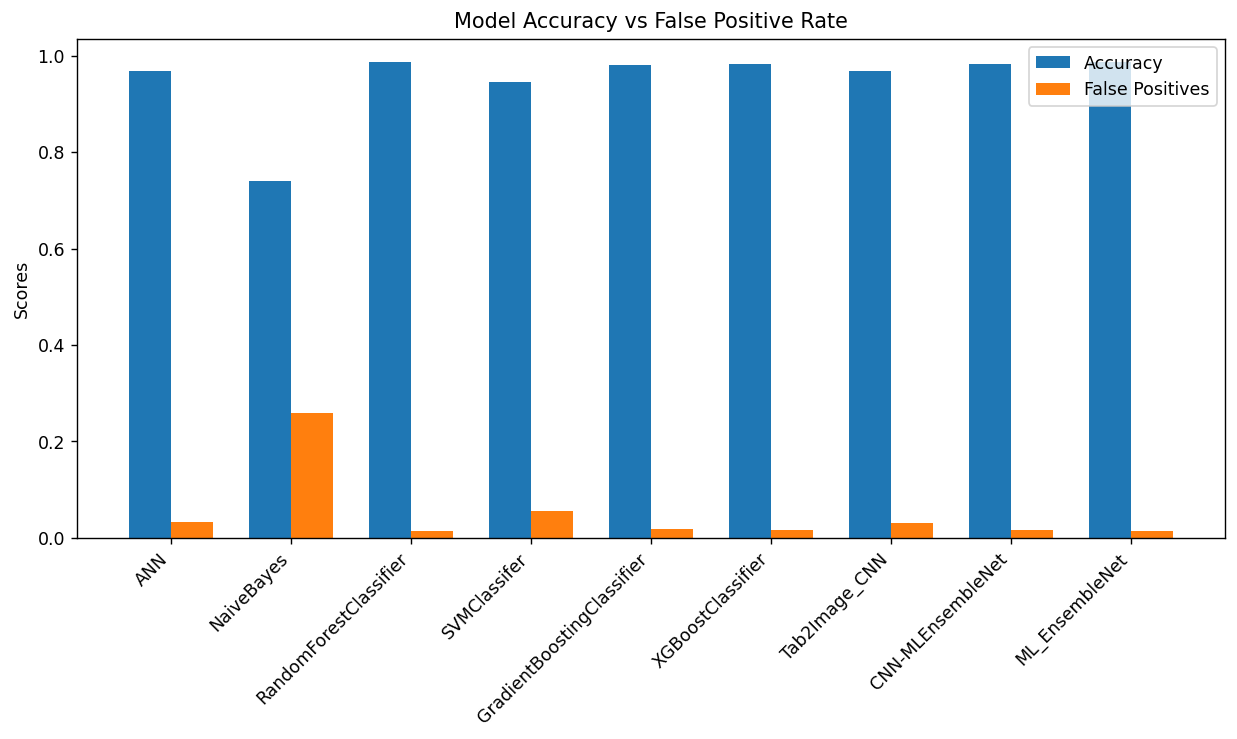

In [4]:
LOG_DETECT_FILE = "detection_log.txt"
LOG_EXPORT_FILE = "export_log.txt"
log_text = None
model_select = None
sample_entry = None
USERS_FILE = "users.json"

def hash_password(password):
    return hashlib.sha256(password.encode()).hexdigest()

def load_users():
    if os.path.exists(USERS_FILE):
        with open(USERS_FILE, 'r') as f:
            return json.load(f)
    return {}

def save_users(users):
    with open(USERS_FILE, 'w') as f:
        json.dump(users, f, indent=4)

def validate_user(username, password):
    users = load_users()
    hashed = hash_password(password)
    return users.get(username) == hashed

def save_user(username, password):
    users = load_users()
    if username in users:
        return False
    users[username] = hash_password(password)
    save_users(users)
    return True

def single_tabular_to_image(sample, img_size=(64, 64)):
    total_pixels = img_size[0] * img_size[1]

    padded = np.zeros(total_pixels)
    padded[:sample.shape[0]] = sample

    image = padded.reshape(img_size[0], img_size[1], 1)
    return np.expand_dims(image, axis=0)  # atch dimension for CNN

def predict_traffic(sample, model, model_name, threshold=0.6):
    if model_name == 'Tab2Image_CNN':
        sample_image = single_tabular_to_image(sample)
        pred_probs = model.predict(sample_image)
        pred_class = np.argmax(pred_probs, axis=1)[0]
    elif model == 1:
        sample_image = single_tabular_to_image(sample)
        cnn_ensemble_preds = models_dict['Tab2Image_CNN'].predict(sample_image)
        sample1 = np.array(sample).reshape(1, -1)
        rf_probs = models_dict['RandomForestClassifier'].predict_proba(sample1)
        xgb_probs = models_dict['XGBoostClassifier'].predict_proba(sample1)
        gbc_probs = models_dict['GradientBoostingClassifier'].predict_proba(sample1)
        # Average the probabilities
        ml_ensemble_probs = (rf_probs + xgb_probs + gbc_probs) / 3
        ensemble_test_probs = (ml_ensemble_probs + cnn_ensemble_preds) / 2
        # Final predicted class
        pred_class = np.argmax(ensemble_test_probs, axis=1)
    elif model == 2:
        sample = np.array(sample).reshape(1, -1)
        # Get prediction probabilities from each model
        rf_probs = models_dict['RandomForestClassifier'].predict_proba(sample)
        xgb_probs = models_dict['XGBoostClassifier'].predict_proba(sample)
        gbc_probs = models_dict['GradientBoostingClassifier'].predict_proba(sample)
        # Average the probabilities
        ensemble_probs = (rf_probs + xgb_probs + gbc_probs) / 3
        # Final predicted class
        pred_class = np.argmax(ensemble_probs)
    elif hasattr(model, 'predict_proba'):
        pred_class = model.predict([sample])[0]
    else:
        pred_class = np.argmax(model.predict(np.array([sample]))[0])
    # Interpret class
    if pred_class == 0:
        return "🚨 ZERO-DAY ATTACK"
    elif pred_class == 1:
        return "💣 RANSOMWARE"
    elif pred_class == 2:
        return "🧪 UNKNOWN / TEST PATTERN"
    elif pred_class == 3:
        return "🧪 BENIGN"
    else:
        return "❓ UNRECOGNIZED"

def check_auto_refresh_var_for_detect_btn(model_name):
    model = models_dict[model_name]
    idx = random.randint(0, len(X_test) - 1)
    sample = X_test[idx]
    if auto_refresh_var.get():
        messagebox.showwarning(
            "Action Blocked",
            "⚠️ You can't perform this action while 🚦 Live Monitoring is ON.\n\nPlease uncheck the box to continue."
        )
    else:
        log_detection(model_name, idx, sample, model, log_to_traffic_box=False)

def detect_traffic(model_name):
    model = models_dict[model_name]
    idx = random.randint(0, len(X_test) - 1)
    sample = X_test[idx]
    log_detection(model_name, idx, sample, model)

def manual_detect():
    model_name = model_select.get()
    sample_str = sample_entry.get()
    if not sample_str.isdigit():
        messagebox.showerror("Invalid Input", f"Sample number must be a number between 0 and {len(X_test)}")
        return
    idx = int(sample_str)
    if not (0 <= idx < len(X_test)):
        messagebox.showerror("Invalid Input", f"Please enter a valid sample number (0-{len(X_test)})")
        return
    model = models_dict[model_name]
    sample = X_test[idx]
    log_detection(model_name, idx, sample, model, force_open_panel=True, log_to_traffic_box=False)

def load_analyst_actions():
    actions = {}
    if os.path.exists("traffic_actions.csv"):
        with open("traffic_actions.csv", mode="r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                key = row["Sample#"]
                actions[key] = row
    return actions

def open_action_history():
    if auto_refresh_var.get():
        messagebox.showinfo("Live Monitoring Active", 
                             "Please disable Live Monitoring first to view Analyst Action History.")
    else:
        if os.path.exists("traffic_actions.csv"):
            if sys.platform == "win32":
                os.startfile("traffic_actions.csv")
            else:
                opener = "open" if sys.platform == "darwin" else "xdg-open"
                subprocess.call([opener, "traffic_actions.csv"])
        else:
            messagebox.showinfo("File Not Found", "No actions recorded yet.")

def open_analyst_panel(model_name, sample_idx, detection_result):
    panel = tk.Toplevel(root)
    panel.title("🧑‍💻 Analyst Action Panel")
    panel.geometry("480x500")
    panel.resizable(False, False)

    # Result Color
    if "ZERO-DAY" in detection_result or "RANSOMWARE" in detection_result:
        det_color = "red"
    elif "UNKNOWN" in detection_result or "TEST" in detection_result:
        det_color = "orange"
    elif "BENIGN" in detection_result:
        det_color = "green"
    else:
        det_color = "black"

    # Header
    tk.Label(panel, text=f"Model: {model_name}", font=("Helvetica", 11, "bold")).pack(pady=4)
    tk.Label(panel, text=f"Sample ID: {sample_idx}", font=("Helvetica", 10)).pack()
    tk.Label(panel, text=f"Result: {detection_result}", font=("Helvetica", 10, "italic"), fg=det_color).pack(pady=2)

    # Previous actions
    all_actions = load_analyst_actions()
    key = str(sample_idx)
    previous_action = all_actions.get(key, {}).get("Action", "")
    action_by = all_actions.get(key, {}).get("Action By", "")
    previous_notes = all_actions.get(key, {}).get("Notes", "")

    if previous_action and action_by == "Manual Action":
        tk.Label(panel, text=f"🕓 Previous Action: {previous_action}", fg="blue", font=("Helvetica", 9)).pack(pady=1)
        if previous_notes:
            tk.Label(panel, text=f"📝 Notes: {previous_notes}", fg="gray", font=("Helvetica", 9), wraplength=440, justify="left").pack(pady=(0, 8))
    elif previous_action:
        tk.Label(panel, text=f"	🤖 Auto Blocked", fg="green", font=("Helvetica", 9)).pack(pady=1)

    # Action options
    tk.Label(panel, text="Select Action:", font=("Helvetica", 10, "bold")).pack(pady=(5, 3))
    action_var = tk.StringVar(value=previous_action)
    options = ["Mark as Safe", "Block Source", "Tag as False Positive"]
    for opt in options:
        tk.Radiobutton(panel, text=opt, variable=action_var, value=opt, font=("Helvetica", 9)).pack(anchor="w", padx=30)

    # Notes box
    tk.Label(panel, text="Add Notes (Optional):", font=("Helvetica", 10)).pack(pady=(8, 2))
    notes_box = tk.Text(panel, height=4, width=50, font=("Helvetica", 9))
    notes_box.pack(pady=2)
    notes_box.insert("1.0", previous_notes)

    # Save Action
    def log_action():
        action = action_var.get()
        notes = notes_box.get("1.0", tk.END).strip()
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

        file_exists = os.path.exists("traffic_actions.csv")
        updated = False
        rows = []

        if file_exists:
            with open("traffic_actions.csv", mode="r", encoding="utf-8") as f:
                reader = csv.DictReader(f)
                for row in reader:
                    if row["Sample#"] == str(sample_idx):
                        row["Model"] = model_name
                        row["Timestamp"] = timestamp
                        row["Detection"] = re.sub(r'[^A-Z/ -]', '', detection_result).strip()
                        row["Action"] = action
                        row["Notes"] = notes
                        row["Action By"] = "Manual Action"
                        updated = True
                    rows.append(row)

        if not updated:
            rows.append({
                "Timestamp": timestamp,
                "Model": model_name,
                "Sample#": sample_idx,
                "Detection": re.sub(r'[^A-Z/ -]', '', detection_result).strip(),
                "Action": action,
                "Notes": notes,
                "Action By": "Manual Action"
            })

        with open("traffic_actions.csv", mode="a", newline='', encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=["Timestamp", "Model", "Sample#", "Detection", "Action", "Notes", "Action By"])
            if not file_exists:
                    writer.writeheader()
            writer.writerows(rows)

        messagebox.showinfo("Saved", "Analyst action recorded.")
        panel.destroy()

    tk.Button(panel, text="💾 Save Action", bg="#007bff", fg="white", font=("Helvetica", 10, "bold"),
              command=log_action).pack(pady=12)


def log_detection(model_name, idx, sample, model, force_open_panel=False, log_to_traffic_box=True):
    result = predict_traffic(sample, model, model_name)
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    log_entry = f"[{timestamp}] {model_name} - Sample #{idx}: {result}\n"

    # Default action
    if ai_block_var.get():
        if "ZERO-DAY" in result or "RANSOMWARE" in result:
            timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    
            file_exists = os.path.exists("traffic_actions.csv")
            updated = False
            rows = []
    
            if file_exists:
                with open("traffic_actions.csv", mode="r", encoding="utf-8") as f:
                    reader = csv.DictReader(f)
                    for row in reader:
                        if row["Sample#"] == str(idx):
                            updated = True
    
            if not updated:
                rows.append({
                    "Timestamp": timestamp,
                    "Model": model_name,
                    "Sample#": idx,
                    "Detection": re.sub(r'[^A-Z/ -]', '', result).strip(),
                    "Action": "Block Source",
                    "Notes": "",
                    "Action By": "Automatic Action"
                })
                with open("traffic_actions.csv", mode="a", newline='', encoding="utf-8") as f:
                    writer = csv.DictWriter(f, fieldnames=["Timestamp", "Model", "Sample#", "Detection", "Action", "Notes", "Action By"])
                    if not file_exists:
                        writer.writeheader()
                    writer.writerows(rows)

    # Determine alert level and color
    if "ZERO-DAY" in result or "RANSOMWARE" in result:
        level = "high"
        tag_color = "#ff0000"
    elif "UNKNOWN" in result or "TEST" in result:
        level = "medium"
        tag_color = "orange"
    elif "BENIGN" in result or "TEST" in result:
        level = "normal"
        tag_color = "green"
    else:
        level = "none"
        tag_color = None

    if log_to_traffic_box:
        # Log visually with tag
        log_text.config(state="normal")
        start = log_text.index("end-1c linestart")
        log_text.insert("end", log_entry)
        end = log_text.index("end-1c lineend")
    
        if tag_color:
            log_text.tag_add(level, start, end)
            log_text.tag_config(level, foreground=tag_color)  # or use background=tag_color for full highlight
    
        log_text.see("end")
        log_text.config(state="disabled")
    
        # Save to file
        with open(LOG_DETECT_FILE, "a", encoding="utf-8") as f:
            f.write(log_entry)

    # Open analyst panel only in manual mode
    if force_open_panel or not auto_refresh_var.get():
        open_analyst_panel(model_name, idx, result)


def show_tooltip(event, text):
    tooltip = tk.Toplevel()
    tooltip.wm_overrideredirect(True)
    x = event.x_root + 10
    y = event.y_root + 10
    tooltip.geometry(f"+{x}+{y}")
    tk.Label(tooltip, text=text, background="lightyellow", relief="solid",
             borderwidth=1, font=("Helvetica", 10), padx=10, pady=5).pack()
    event.widget.tooltip = tooltip

def hide_tooltip(event):
    if hasattr(event.widget, 'tooltip'):
        event.widget.tooltip.destroy()
        del event.widget.tooltip

def clear_log():
    log_text.config(state="normal")
    log_text.delete("1.0", tk.END)
    log_text.config(state="disabled")
    if os.path.exists(LOG_DETECT_FILE):
        os.remove(LOG_DETECT_FILE)

def export_log():
    content = log_text.get("1.0", tk.END).strip()
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    if not content:
        messagebox.showinfo("Export Log", "No logs to export.")
        return
    with open(LOG_EXPORT_FILE, "a", encoding="utf-8") as f:
        f.write(f"\n\n=== Exported Log [{timestamp}] ===\n")
        f.write(content + "\n")
    messagebox.showinfo("Export Log", f"Logs appended to '{LOG_EXPORT_FILE}'")

def show_stats():
    stats_win = tk.Toplevel(root)
    stats_win.title("Model Statistics")
    fig, ax = plt.subplots(figsize=(10, 6))
    model_names = list(accuracies.keys())
    acc_values = [accuracies[m] for m in model_names]
    fp_values = [false_positives[m] for m in model_names]

    x = np.arange(len(model_names))
    width = 0.35
    ax.bar(x - width/2, acc_values, width, label='Accuracy')
    ax.bar(x + width/2, fp_values, width, label='False Positives')
    ax.set_ylabel('Scores')
    ax.set_title('Model Accuracy vs False Positive Rate')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.legend()
    fig.tight_layout()
    canvas = FigureCanvasTkAgg(fig, master=stats_win)
    canvas.draw()
    canvas.get_tk_widget().pack(fill="both", expand=True)

def auto_refresh():
    if auto_refresh_var.get():
        detect_traffic('RandomForestClassifier')
    root.after(2000, auto_refresh)  # re-check every 2 seconds


def show_welcome_screen():
    screen_width = root.winfo_screenwidth()
    screen_height = root.winfo_screenheight()

    splash_width = int(screen_width * 0.5)   # Increased from 0.4
    splash_height = int(screen_height * 0.55) # Increased from 0.4
    x = (screen_width - splash_width) // 2
    y = (screen_height - splash_height) // 2

    splash = tk.Toplevel(root)
    splash.overrideredirect(True)
    splash.geometry(f"{splash_width}x{splash_height}+{x}+{y}")
    splash.configure(bg="white")

    def render_background():
        try:
            bg_image = Image.open("image/background.png").resize((splash_width, splash_height), Image.Resampling.LANCZOS)
            draw = ImageDraw.Draw(bg_image)
            bg_photo = ImageTk.PhotoImage(bg_image)
            splash.bg_photo = bg_photo
            bg_label = tk.Label(splash, image=bg_photo, bd=0)
            bg_label.place(relwidth=1, relheight=1)

        except Exception as e:
            print(f"[!] Error loading splash background: {e}")

    splash.after(100, render_background)

    def close_splash():
        if splash.winfo_exists():
            splash.destroy()
        show_login_window()  # ✅ Splash ke baad directly login screen


    splash.after(4000, close_splash)

def show_login_window():
    screen_width = root.winfo_screenwidth()
    screen_height = root.winfo_screenheight()
    login_width = int(screen_width * 0.5)
    login_height = int(screen_height * 0.5)
    x = (screen_width - login_width) // 2
    y = (screen_height - login_height) // 2

    login_win = tk.Toplevel(root)
    login_win.title("🔐 Login to Hermes")
    login_win.geometry(f"{login_width}x{login_height}+{x}+{y}")
    login_win.configure(bg="#eaf6ff")
    login_win.grab_set()
    login_win.resizable(False, False)
    login_win.protocol("WM_DELETE_WINDOW", root.destroy)

    header_font = ("Helvetica", int(login_height * 0.06), "bold")
    label_font = ("Helvetica", int(login_height * 0.035))
    entry_font = ("Helvetica", int(login_height * 0.035))
    button_font = ("Helvetica", int(login_height * 0.035), "bold")

    tk.Label(login_win, text="🔐 Welcome to Hermes", font=header_font,
             bg="#eaf6ff", fg="#003366").pack(pady=(int(login_height * 0.07), 10))

    tk.Label(login_win, text="👤 Username", bg="#eaf6ff", font=label_font).pack(pady=(10, 0))
    username_entry = tk.Entry(login_win, font=entry_font, justify='center')
    username_entry.pack(pady=5, ipadx=10)

    tk.Label(login_win, text="🔒 Password", bg="#eaf6ff", font=label_font).pack(pady=(10, 0))
    password_entry = tk.Entry(login_win, font=entry_font, show="*", justify='center')
    password_entry.pack(pady=5, ipadx=10)

    def try_login():
        uname = username_entry.get()
        passwd = password_entry.get()
        if validate_user(uname, passwd):
            if uname == "Admin":
                # Ask Admin whether they want to create an account
                response = messagebox.askyesno("Admin Access", f"✅ Welcome, {uname}!\nDo you want to create a new user account?")
                if response:
                    create_btn.config(state="normal")  # Enable create account
                    messagebox.showinfo("Info", "🆕 Fill in the fields above and click 'Create Account'")
                else:
                    login_win.destroy()
                    root.deiconify()
                    start_main_app()
                    return  # Avoid running next line
            else:
                messagebox.showinfo("Success", f"✅ Welcome, {uname}!")
                login_win.destroy()
                root.deiconify()
                start_main_app()
        else:
            messagebox.showerror("Login Failed", "❌ Invalid username or password!")

    def try_register():
        # Only Admin can reach here, so no check needed
        uname = username_entry.get()
        passwd = password_entry.get()
        if len(passwd) < 8 or not any(c.isupper() for c in passwd) or not any(c.isdigit() for c in passwd):
            messagebox.showwarning("Weak Password", "Password must be at least 8 characters, include 1 digit and 1 uppercase.")
            return
        if save_user(uname, passwd):
            messagebox.showinfo("Account Created", "✅ Account created!")
        else:
            messagebox.showerror("Exists", "⚠️ Username already exists!")

    btn_frame = tk.Frame(login_win, bg="#eaf6ff")
    btn_frame.pack(pady=(20, 0))

    tk.Button(btn_frame, text="🔐 Login", font=button_font,
              bg="#007bff", fg="white", padx=15, pady=5,
              command=try_login).pack(side="left", padx=10)

    create_btn = tk.Button(btn_frame, text="🆕 Create Account", font=button_font,
                           bg="white", relief="solid", padx=15, pady=5,
                           command=try_register, state="disabled")  # Initially disabled
    create_btn.pack(side="left", padx=10)


def start_main_app():
    global auto_refresh_var
    
    root.title("Hermes")
    root.state('zoomed')
    root.configure(bg="#eaf6ff")
    root.protocol("WM_DELETE_WINDOW", on_close)
    
    auto_refresh_var = tk.BooleanVar()
    root.after(2000, auto_refresh)
    
    # Modify the main frame and sub-frames configuration
    main_frame = tk.Frame(root, bg="#eaf6ff")
    main_frame.pack(fill="both", expand=True)
    
    # Left frame (models section)
    left_frame = tk.Frame(main_frame, bg="#eaf6ff")
    #left_frame.pack(side="left", fill="both", expand=True)
    
    # Right frame (log section)
    right_frame = tk.Frame(main_frame, bg="#eaf6ff", width=400)  # Fixed minimum width
    #right_frame.pack(side="right", fill="y", expand=False)
    
    main_frame.grid_columnconfigure(0, weight=3)  # Left frame gets 3/4 of space
    main_frame.grid_columnconfigure(1, weight=1)  # Right frame gets 1/4 of space
    main_frame.grid_rowconfigure(0, weight=1)
    
    left_frame.grid(row=0, column=0, sticky="nsew")
    right_frame.grid(row=0, column=1, sticky="nsew", ipadx=10)
    right_frame.config(width=400)  # Fixed width
    
    header = tk.Frame(left_frame, bg="#eaf6ff")
    header.pack(pady=(10,10), fill="x")
    
    title_label = tk.Label(header, text="🔐 Intrusion Detection Dashboard",
                           font=("Helvetica", 24, "bold"), fg="#003366", bg="#eaf6ff")
    title_label.pack(side="left", padx=(10, 0))
    
    # Load icons early
    stats_icon_img = Image.open("image/stats_icon.png").resize((20, 20), Image.Resampling.LANCZOS)
    stats_icon = ImageTk.PhotoImage(stats_icon_img)
    
    info_icon_img = Image.open("image/help.png").resize((20, 20), Image.Resampling.LANCZOS)
    info_icon = ImageTk.PhotoImage(info_icon_img)
    
    # Store references globally to prevent GC
    root.icon_refs = [stats_icon, info_icon]
    
    
    stats_btn = tk.Button(header, image=stats_icon, text=" Stats", compound="left", command=show_stats,
                          bg="white", fg="black", font=("Helvetica", 12, "bold"),
                          relief="solid", borderwidth=1, padx=5)
    stats_btn.image = stats_icon  # Prevent garbage collection
    stats_btn.pack(side="right", padx=5)
    
    def show_explainability():
        popup = tk.Toplevel(root)
        popup.title("🔍 Feature Importance (Explainability)")
        popup.geometry("1000x600")
        popup.minsize(600, 400)
    
        frame = tk.Frame(popup)
        frame.pack(fill="both", expand=True)
    
        rf = models_dict.get('RandomForestClassifier')
        scores = rf.feature_importances_
        feature_scores = pd.Series(scores, index=features).sort_values(ascending=True)
    
        fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
        bars = ax.barh(feature_scores.index, feature_scores.values, color='lightgreen')
        ax.set_title("Feature Importance for Detection (RandomForestClassifier)", fontsize=14)
        ax.set_xlabel("Importance Score", fontsize=12)
        ax.set_ylabel("Features", fontsize=12)
    
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax.text(width + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{feature_scores.values[i]:.3f}", va='center', fontsize=9)
    
        # Tighten layout to avoid white space and overflow
        fig.subplots_adjust(left=0.18, right=0.92)
    
        canvas = FigureCanvasTkAgg(fig, master=frame)
        canvas_widget = canvas.get_tk_widget()
        canvas_widget.pack(fill="both", expand=True)
        canvas.draw()
    
        def resize_graph(event):
            new_width = event.width / 100
            new_height = event.height / 100
            fig.set_size_inches(new_width, new_height)
            fig.subplots_adjust(left=0.18, right=0.92)
            canvas.draw()
    
        canvas_widget.bind("<Configure>", resize_graph)
    
    
    
    
    explain_btn = tk.Button(header, text="🧠 Feature Importance", command=show_explainability,
                            bg="white", fg="black", font=("Helvetica", 12, "bold"),
                            relief="solid", borderwidth=1, padx=5)
    explain_btn.pack(side="right", padx=5)
    
    def show_help_popup():
        popup = tk.Toplevel(root)
        popup.title("📘 Help Guide")
        popup.configure(bg="#ecf4ff")
        popup.geometry("620x630")
        popup.resizable(False, False)
    
        # 🔷 Header
        header_frame = tk.Frame(popup, bg="#003366", pady=10)
        header_frame.pack(fill="x")
    
        title = tk.Label(header_frame, text="🛡️How to Use the Intrusion Detection Dashboard",
                         font=("Helvetica", 14, "bold"), bg="#003366", fg="white")
        title.pack()
    
        # 📄 Body
        content_frame = tk.Frame(popup, bg="#ffffff", padx=20, pady=15)
        content_frame.pack(fill="both", expand=True)
    
        help_text = (
            "1. Detect Traffic\n"
            "  1.1 Click 'Detect Traffic' on any model card to analyze a sample.\n"
            "  1.2 After prediction, choose an action:\n"
            "      ☑️ Be Safe    🔒 Block    🕵️ Tag as False Positive\n"
            "  1.3 Your action will be saved and shown on future re-checks.\n\n"
    
            "2. Manual Check\n"
            "  2.1 Pick a model and sample number, then click 'Detect'.\n"
            "  2.2 If the sample has been analyzed earlier, previous prediction and action will be shown.\n"
            "  2.3 You can modify or update your action anytime.\n\n"
    
            "3. Live Monitoring\n"
            "  3.1 Enable the 'Live Monitoring' checkbox to auto-scan traffic.\n"
            "  3.2 Manual actions can still be taken in real-time.\n\n"
    
            "4. Export Log\n"
            "  4.1 Click 'Export Log' to save all predictions & actions.\n"
            "  4.2 The log file is stored in the 'Hermes' folder as 'export_log.txt'.\n\n"
    
            "💡 Tip: You can re-check or update your decisions anytime!"
        )
    
        text_box = tk.Text(content_frame, height=20, wrap="word", bg="#ffffff",
                           fg="#2c3e50", font=("Segoe UI", 10), relief="flat", bd=0)
        text_box.insert("1.0", help_text)
        text_box.config(state="disabled")
        text_box.pack(fill="both", expand=True)
    
        # 🔘 Close Button
        footer_frame = tk.Frame(popup, bg="#ecf4ff", pady=10)
        footer_frame.pack(fill="x")
    
        close_btn = tk.Button(footer_frame, text="✖ Close", font=("Helvetica", 10, "bold"),
                              bg="#007bff", fg="white", padx=5, pady=2,
                              relief="ridge", command=popup.destroy)
        close_btn.pack()
    
    info_btn = tk.Button(header, image=info_icon, text=" Help", compound="left",
                         bg="white", fg="black", font=("Helvetica", 12, "bold"),
                         relief="solid", borderwidth=1, padx=5,
                         command=show_help_popup)
    info_btn.image = info_icon  # Prevent garbage collection
    info_btn.pack(side="right", padx=5)
    
    
    # Replace the existing cards_frame creation with this:
    cards_frame = tk.Frame(left_frame, bg="#eaf6ff")
    cards_frame.pack(pady=(0,30), fill="both", expand=True)
    
    # Configure grid weights for the cards
    for i in range(3):  # Assuming 3 columns
        cards_frame.columnconfigure(i, weight=1, uniform="cards")
        
    for i in range((len(models_list) + 2) // 3):  # Enough rows for all models
        cards_frame.rowconfigure(i, weight=1)
    
    for i, model_name in enumerate(models_list):
    
        acc = accuracies[model_name]
        fp = false_positives[model_name]
    
        # Decide risk level and assign refined background color
        if acc >= 0.98 and fp <= 0.02:
            risk = "🟢 Highly Recommended"
            bg_color = "#81c784"  # Soft green
            fg_color = "black"
        elif acc >= 0.95 and fp <= 0.05:
            risk = "🟡 Recommended"
            bg_color = "#fff176"  # Warm yellow
            fg_color = "black"
        elif acc >= 0.90 and fp <= 0.08:
            risk = "🟡 Less Recommended"
            bg_color = "orange"  # Warm yellow
            fg_color = "white"
        else:
            risk = "🔴 Not Recommended"
            bg_color = "#ff4d4d"  # Clear red
            fg_color = "white"
    
        card = tk.Frame(cards_frame, bd=1, relief=tk.SOLID, padx=10, pady=15, bg=bg_color)
        card.grid(row=i//3, column=i%3, padx=10, pady=10, sticky="nsew")
        
        # Configure card grid to use all space
        card.grid_rowconfigure(0, weight=1)  # Model name
        card.grid_rowconfigure(1, weight=1)  # Accuracy
        card.grid_rowconfigure(2, weight=1)  # FP rate
        card.grid_rowconfigure(3, weight=1)  # Recommendation
        card.grid_rowconfigure(4, weight=1)  # Button (increased from 2 to give more space)
        card.grid_columnconfigure(0, weight=1)
        
        # Model name - top
        model_label = tk.Label(card, text=f"🧠 {model_name}", 
                             font=("Helvetica", 14, "bold"),
                             bg=bg_color, fg=fg_color)
        model_label.grid(row=0, column=0, sticky="nsew", pady=(0,5))
        
        # Accuracy - middle top
        acc_label = tk.Label(card, text=f"✅ Accuracy: {acc*100:.2f}%", 
                            font=("Helvetica", 12),
                            bg=bg_color, fg=fg_color)
        acc_label.grid(row=1, column=0, sticky="nsew")
        acc_label.bind("<Enter>", lambda e, val=acc: show_tooltip(e, f"📊 Accuracy\n{val*100:.2f}% - Higher is better"))
        acc_label.bind("<Leave>", hide_tooltip)
        
        # False Positive - middle
        fp_label = tk.Label(card, text=f"❌ False Positives: {fp*100:.2f}%", 
                           font=("Helvetica", 10),
                           bg=bg_color, fg=fg_color)
        fp_label.grid(row=2, column=0, sticky="nsew")
        fp_label.bind("<Enter>", lambda e, val=fp: show_tooltip(e, f"🔍 FP Rate\n{val*100:.2f}% - Lower is better"))
        fp_label.bind("<Leave>", hide_tooltip)
        
        # Recommendation - middle bottom
        risk_label = tk.Label(card, text=risk, 
                             font=("Helvetica", 10, "italic"),
                             bg=bg_color, fg=fg_color)
        risk_label.grid(row=3, column=0, sticky="nsew", pady=(5,0))
        
        # Button - bottom (expands to fill remaining space)
        detect_btn = tk.Button(card, text="Detect Traffic", 
                              font=("Helvetica", 10),
                              bg="#007bff", fg="white",
                              command=lambda m=model_name: check_auto_refresh_var_for_detect_btn(m))
        detect_btn.grid(row=4, column=0, sticky="nsew", pady=(10,0), padx=40)
    
    # --- Traffic Log Section Header ---
    traffic_header = tk.Frame(right_frame, bg="#eaf6ff")
    traffic_header.pack(fill="x", pady=(10, 0))
    
    tk.Label(
        traffic_header,
        text="🕵 Live Traffic Log",
        font=("Helvetica", 14, "bold"),
        bg="#eaf6ff"
    ).pack(side="left", padx=(10, 0))
    
    # --- Checkboxes Frame just BELOW the header ---
    checkbox_frame = tk.Frame(right_frame, bg="#eaf6ff")
    checkbox_frame.pack(fill="x", padx=10, pady=(2, 5))  # Small padding below header
    
    # Live Monitoring Checkbox - Left aligned
    auto_refresh_var = tk.BooleanVar()
    auto_refresh_checkbox = tk.Checkbutton(
        checkbox_frame,
        text="🚦 Live Monitoring",
        variable=auto_refresh_var,
        font=("Helvetica", 10),
        bg="#eaf6ff"
    )
    auto_refresh_checkbox.pack(side="left")
    
    # AI Blocking Checkbox - Right aligned
    global ai_block_var
    ai_block_var = tk.BooleanVar()
    ai_block_checkbox = tk.Checkbutton(
        checkbox_frame,
        text="🤖 Enable AI Blocking",
        variable=ai_block_var,
        font=("Helvetica", 10),
        bg="#eaf6ff"
    )
    ai_block_checkbox.pack(side="right")

    
    # Log text area
    log_frame = tk.Frame(right_frame, bg="white", bd=1, relief=tk.SUNKEN)
    log_frame.pack(fill="both", expand=True, padx=10, pady=(5, 10))
    
    log_scroll = tk.Scrollbar(log_frame)
    log_scroll.pack(side="right", fill="y")

    global log_text
    log_text = tk.Text(log_frame, height=25, width=50, font=("Courier", 10), 
                       bg="black", fg="white", yscrollcommand=log_scroll.set)
    log_text.pack(fill="both", expand=True, padx=1, pady=1)
    
    log_scroll.config(command=log_text.yview)
    
    # Action buttons
    btn_frame = tk.Frame(right_frame, bg="#eaf6ff")
    btn_frame.pack(fill="x", padx=10, pady=(0, 0))
    
    tk.Button(btn_frame, text="Clear All", command=clear_log, 
              bg="white", relief="solid", padx=10).pack(side="left", padx=5)
    tk.Button(btn_frame, text="Export Log", command=export_log, 
              bg="white", relief="solid", padx=10).pack(side="left", padx=5)
    tk.Button(btn_frame, text="Analyst Action History", command=open_action_history,
              bg="#4CAF50", fg="white", relief="solid", padx=10).pack(side="right", padx=5)
    
    # Manual detection panel
    manual_card = tk.Frame(right_frame, bg="#f0f0f0", bd=2, relief=tk.SOLID)
    manual_card.pack(fill="both", expand=True, padx=10, pady=10)
    
    # Configure grid weights
    manual_card.grid_rowconfigure(0, weight=1)  # Title
    manual_card.grid_rowconfigure(1, weight=1)  # Model select label
    manual_card.grid_rowconfigure(2, weight=1)  # Model combobox
    manual_card.grid_rowconfigure(3, weight=1)  # Sample number label
    manual_card.grid_rowconfigure(4, weight=1)  # Sample entry
    manual_card.grid_rowconfigure(5, weight=1)  # Button
    manual_card.grid_columnconfigure(0, weight=1)
    
    # 1. Bigger Title (Increased from 12 to 14)
    manual_title = tk.Label(
        manual_card, 
        text="🛠 Manual Check", 
        font=("Helvetica", 14, "bold"),  # Increased from 12
        bg="#f0f0f0"
    )
    manual_title.grid(row=0, column=0, sticky="nsew", pady=(0, 10))

    # 2. Bigger Label for "Select Model" (Increased from default to 12)
    tk.Label(
        manual_card, 
        text="Select Model", 
        font=("Helvetica", 12),  # Increased
        bg="#f0f0f0"
    ).grid(row=1, column=0, sticky="w", padx=5)
    
    # 3. Bigger Combobox Font (Increased)
    global model_select
    model_select = ttk.Combobox(
        manual_card, 
        values=models_list, 
        state="readonly",
        font=("Helvetica", 12)  # Increased
    )
    model_select.current(0)
    model_select.grid(row=2, column=0, sticky="ew", padx=5, pady=(0, 10))
    
    # 4. Bigger Label for "Sample Number" (Increased from default to 12)
    tk.Label(
        manual_card, 
        text=f"Sample Number (0-{len(X_test)})", 
        font=("Helvetica", 12),  # Increased
        bg="#f0f0f0"
    ).grid(row=3, column=0, sticky="w", padx=5)

    # 5. Bigger Entry Widget Font (Increased)
    global sample_entry
    sample_entry = tk.Entry(
        manual_card,
        font=("Helvetica", 12)  # Increased
    )
    sample_entry.insert(0, "0")
    sample_entry.grid(row=4, column=0, sticky="ew", padx=5, pady=(0, 20))
    
    # 6. Button
    manual_btn = tk.Button(
        manual_card, 
        text="Detect", 
        font=("Helvetica", 12, "bold"),  # Increased from 10 to 12 + added bold
        bg="#28a745", 
        fg="white",
        command=manual_detect
    )
    manual_btn.grid(row=5, column=0, sticky="nsew", padx=5, pady=(0, 10))

    def on_resize(event):
        win_width = root.winfo_width()
        base_font_size = max(12, min(14, win_width // 80))  # Adjusted min/max
        
        # Apply only to widgets where dynamic sizing is needed
        title_label.config(font=("Helvetica", base_font_size + 4, "bold"))  # Bigger title
        
        # For cards, ensure they don't shrink below 12pt
        for card in cards_frame.winfo_children():
            for widget in card.winfo_children():
                if isinstance(widget, tk.Label):
                    current_font = widget.cget("font")
                    if isinstance(current_font, str):
                        font_parts = current_font.split()
                        font_family = font_parts[0]
                        font_style = tuple(font_parts[2:]) if len(font_parts) > 2 else ()
                    elif isinstance(current_font, tuple):
                        font_family = current_font[0]
                        font_style = current_font[2:] if len(current_font) > 2 else ()
                    new_font = (font_family, base_font_size) + font_style
                    widget.config(font=new_font)
        
        # List of widgets that should have dynamic font sizes
        dynamic_widgets1 = [
            stats_btn, explain_btn, info_btn]
        dynamic_widgets = [
            *[child for card in cards_frame.winfo_children() 
              for child in card.winfo_children() 
              if isinstance(child, (tk.Label, tk.Button))]
        ]
    
        for widget in dynamic_widgets1:
            if 'font' in widget.config():
                current_font = widget.cget('font')
                if isinstance(current_font, str):
                    font_parts = current_font.split()
                    new_font = (font_parts[0], base_font_size-2) + tuple(font_parts[2:])
                elif isinstance(current_font, tuple):
                    new_font = (current_font[0], base_font_size-2) + current_font[2:]
                widget.config(font=new_font)
        
        for widget in dynamic_widgets:
            if 'font' in widget.config():
                current_font = widget.cget('font')
                if isinstance(current_font, str):
                    font_parts = current_font.split()
                    new_font = (font_parts[0], base_font_size) + tuple(font_parts[2:])
                elif isinstance(current_font, tuple):
                    new_font = (current_font[0], base_font_size) + current_font[2:]
                widget.config(font=new_font)
    
    root.bind('<Configure>', on_resize)
    # This should be the last line before mainloop()
    footer = tk.Label(root, text="Developed by Team Hermes", font=("Helvetica", 12, "italic"),
                      fg="#666", bg="#eaf6ff")
    footer.place(relx=0.5, rely=1.0, anchor="s", y=-10)

def on_close():
    if root.winfo_exists():
        try:
            if os.path.exists(LOG_DETECT_FILE):
                os.remove(LOG_DETECT_FILE)
            root.destroy()
        except:
            pass

# MAIN PROGRAM
root = tk.Tk()
auto_refresh_var = None
ai_block_var = None
root.withdraw()  # Hide initially
show_welcome_screen()
root.mainloop()